In [7]:
library(repr)
library(tidyverse)

In [8]:
options(repr.plot.width=8, repr.plot.height=6, repr.plot.res = 300)
library(showtext)
font_add_google("Lato", "lato")
showtext_opts(dpi = 300)
showtext_auto()

In [20]:
df <- read_csv("io_group_gaze.csv")
df <- df |> 
    mutate(
        inside = factor(inside),
        inside = fct_recode(inside, "outside" = "0", "inside" = "1"),
        PID = factor(PID)
    ) |>
    rename(
        building_location = inside,
        group = category
    )

Rows: 1829 Columns: 6
── Column specification ────────────────────────────────────────────────────────────────────────────────────────────────
Delimiter: ","
chr (2): hitObjectColliderName, category
dbl (4): PID, inside, GroupCount, median_clusterDuration

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


In [13]:
# df |> ggplot(aes(x = group, y = median_clusterDuration, color = building_location)) +
#  geom_point(position = position_dodge(0.4)) +
#  theme_minimal()
df |> head()

PID,hitObjectColliderName,group,building_location,GroupCount,median_clusterDuration
<dbl>,<chr>,<fct>,<fct>,<dbl>,<dbl>
2002,Building_100,control,outside,10,0.3832777
2002,Building_101,control,outside,21,0.5343921
2002,Building_102,control,outside,4,0.9105198
2002,Building_108,control,outside,2,0.5216707
2002,Building_109,control,outside,1,0.2677307
2002,Building_140,control,outside,1,0.2887373


In [21]:
fig <- df |>
  ggplot(aes(x = median_clusterDuration, group = PID)) +
  geom_density(alpha = 0.6) +  # Adjust alpha for transparency
  xlim(0, 1) +
  facet_wrap(~ interaction(group, building_location)) +  # Facet by the interaction of the two factors
  theme_minimal() +
  labs(title = "Density Plot for Each Combination of Factors",
       x = "median cluster duration for each building (s)",
       y = "density")
ggsave("naisu_only_location.svg", fig)

Saving 6.67 x 6.67 in image
Warning message:
“Removed 55 rows containing non-finite outside the scale range (`stat_density()`).”


In [41]:
library(lme4)
library(emmeans)

# Fit a generalized linear mixed model (GLMM) using glmer
# Assuming a dataset 'data' with a binary response variable 'y', 
# a fixed effect 'x', and a random effect 'group'

model <- glmer(median_clusterDuration ~ building_location + group + (1 | PID) + (1 | hitObjectColliderName), data = df, Gamma(link = "inverse"))

ERROR: Error in library(emmeans): there is no package called ‘emmeans’


In [40]:
model

Generalized linear mixed model fit by maximum likelihood (Laplace
  Approximation) [glmerMod]
 Family: Gamma  ( inverse )
Formula: median_clusterDuration ~ building_location + group + (1 | PID) +  
    (1 | hitObjectColliderName)
   Data: df
       AIC        BIC     logLik   deviance   df.resid 
-1865.4538 -1826.8732   939.7269 -1879.4538       1822 
Random effects:
 Groups                Name        Std.Dev.
 hitObjectColliderName (Intercept) 0.2845  
 PID                   (Intercept) 0.1202  
 Residual                          0.3688  
Number of obs: 1829, groups:  hitObjectColliderName, 127; PID, 24
Fixed Effects:
            (Intercept)  building_locationinside             groupcontrol  
                 2.6867                  -0.3545                  -0.1874  
        groupperipheral  
                -0.4871  

In [13]:
df_node <- read_csv("io_node_group_gaze.csv")

df_node <- df_node |> 
    mutate(
        inside = factor(inside),
        inside = fct_recode(inside, "outside" = "0", "inside" = "1"),
        hitObjectColliderName = factor(hitObjectColliderName),
        PID = factor(PID),
        category = factor(category)
    ) |>
    rename(
        building_location = inside,
        group = category,
        building = hitObjectColliderName,
        duration = clusterDuration
    )

df_node |> head()


Rows: 17925 Columns: 8
── Column specification ────────────────────────────────────────────────────────────────────────────────────────────────
Delimiter: ","
chr (2): hitObjectColliderName, category
dbl (6): clusterID, sampleNr, clusterDuration, PID, inside, connections

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


clusterID,sampleNr,duration,building,PID,group,building_location,connections
<dbl>,<dbl>,<dbl>,<fct>,<fct>,<fct>,<fct>,<dbl>
2,121,1.3477349,TaskBuilding_35,4003,peripheral,inside,17
7,35,0.3888457,Building_166,4003,peripheral,inside,12
9,39,0.4330869,Building_168,4003,peripheral,inside,11
10,33,0.3671408,TaskBuilding_42,4003,peripheral,inside,12
12,57,0.6329131,Building_166,4003,peripheral,inside,12
13,56,0.6199913,Building_166,4003,peripheral,inside,12


`summarise()` has grouped output by 'PID', 'building', 'group', 'building_location'. You can override using the
`.groups` argument.
Warning message:
“Removed 7 rows containing non-finite outside the scale range (`stat_density()`).”


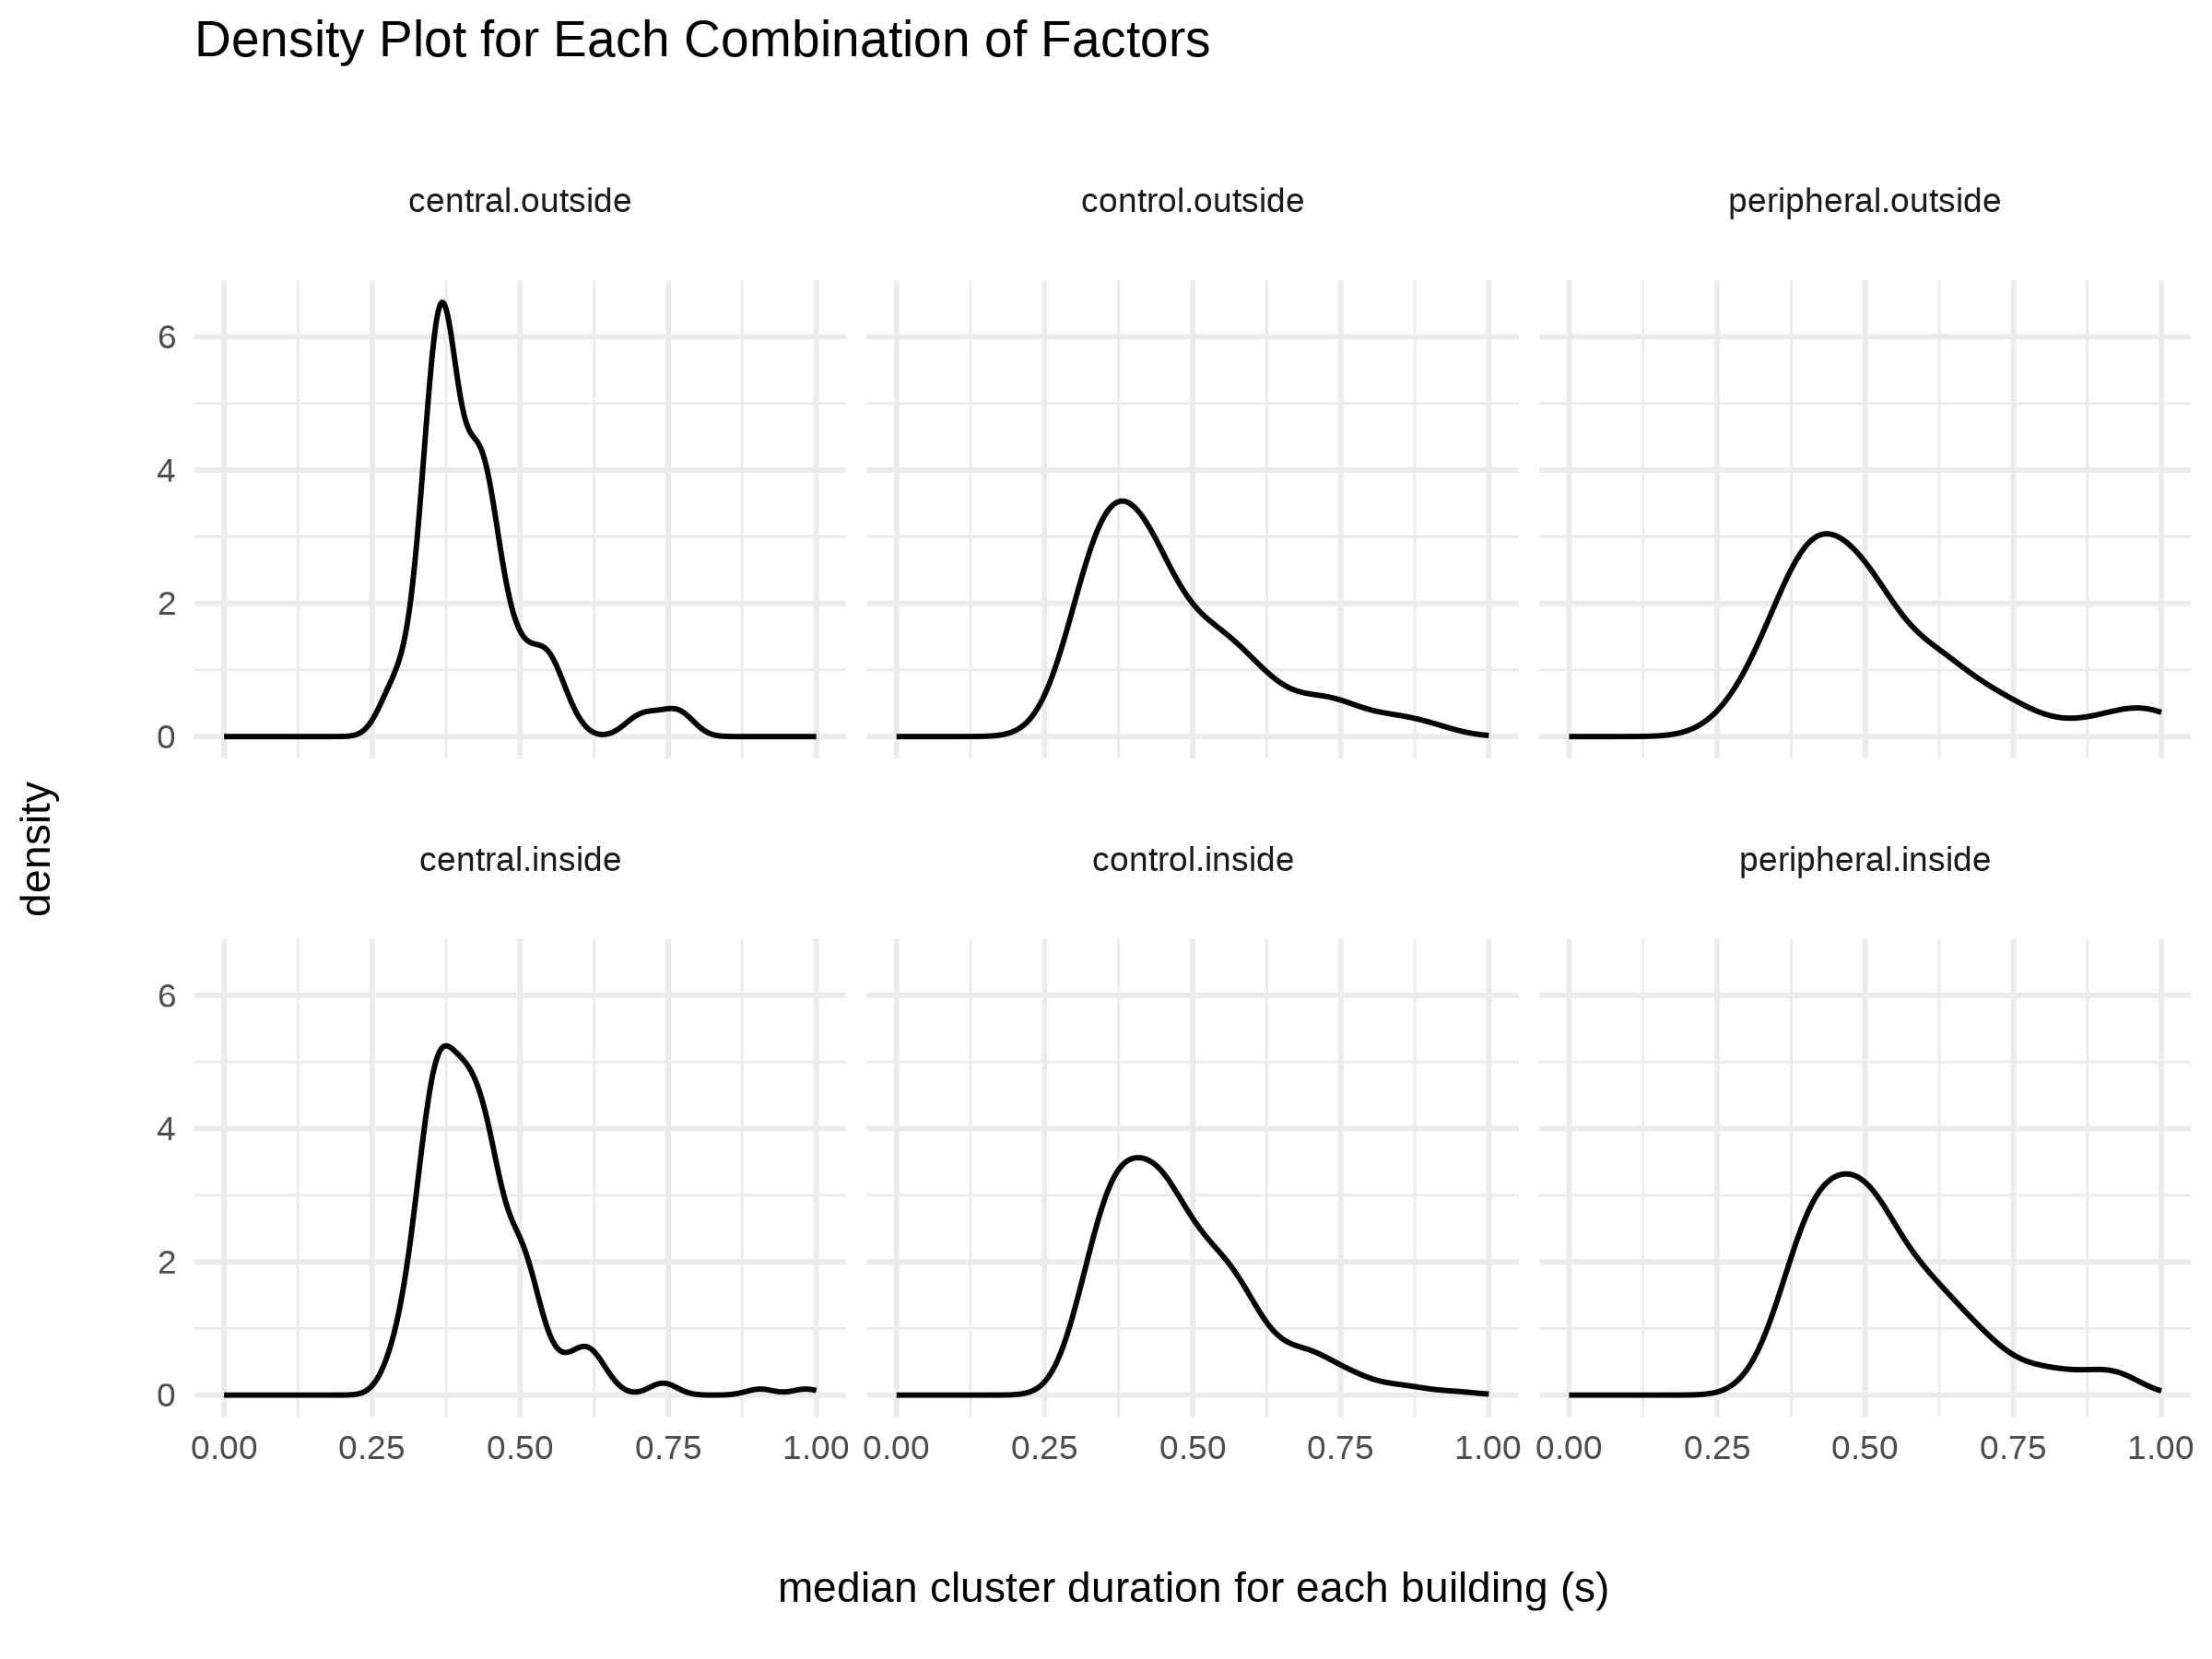

In [38]:
df_node |>
    group_by(PID, building, group, building_location, connections) |>
    summarise(median_duration = median(duration)) |>
    ungroup() |>
    filter(connections > 5) |>
    ggplot(aes(x = median_duration)) +
      geom_density(alpha = 0.6) +  # Adjust alpha for transparency
      xlim(0,1)+
      facet_wrap(~ interaction(group, building_location)) +  # Facet by the interaction of the two factors
      theme_minimal() +
      labs(title = "Density Plot for Each Combination of Factors",
           x = "median cluster duration for each building (s)",
           y = "density")


Warning message:
“Removed 848 rows containing non-finite outside the scale range (`stat_density()`).”
Saving 6.67 x 6.67 in image


ERROR: Error in eval(expr, envir, enclos): object 'fig' not found


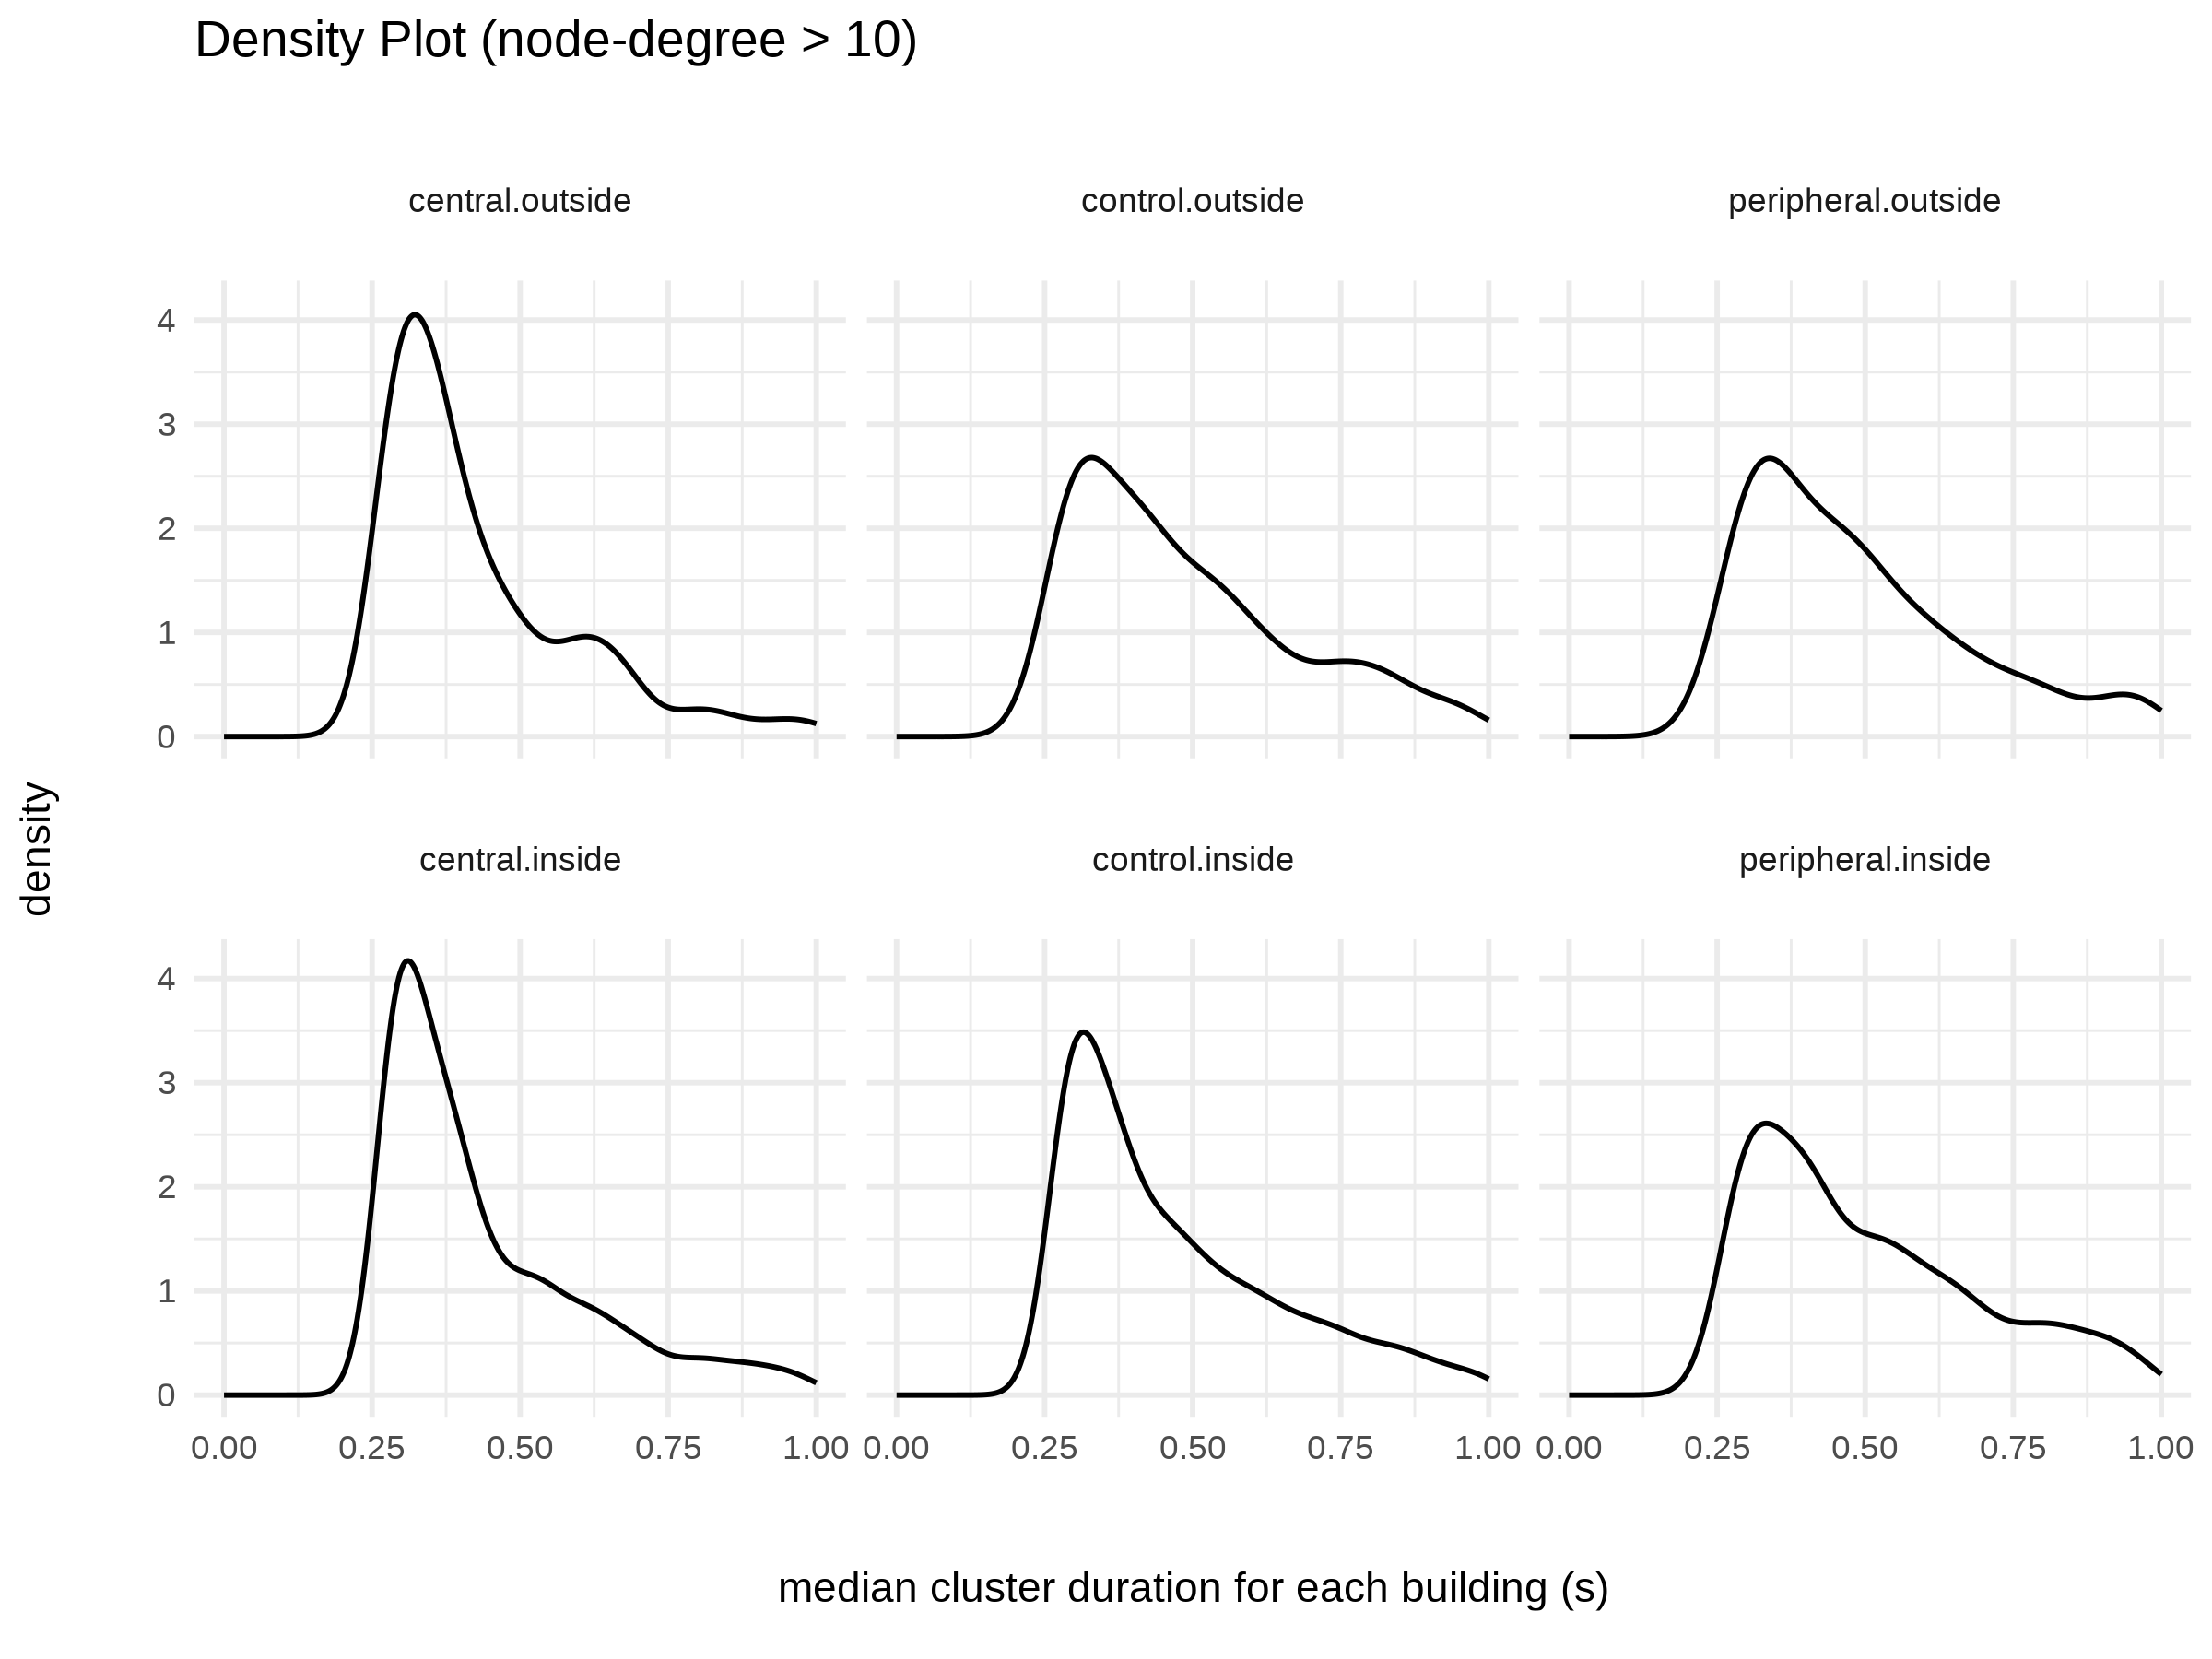

In [49]:
df_node |>
    group_by(PID, building, group, building_location, connections) |>
    ungroup() |>
    filter(connections > 10) |>
    ggplot(aes(x = duration)) +
      geom_density(alpha = 0.6) +  # Adjust alpha for transparency
      xlim(0,1)+
      facet_wrap(~ interaction(group, building_location)) +  # Facet by the interaction of the two factors
      theme_minimal() +
      labs(title = "Density Plot (node-degree > 10)",
           x = "median cluster duration for each building (s)",
           y = "density")
ggsave("naisu_only_location_node_filter.svg", fig)

Warning message:
“Removed 2585 rows containing non-finite outside the scale range (`stat_density()`).”


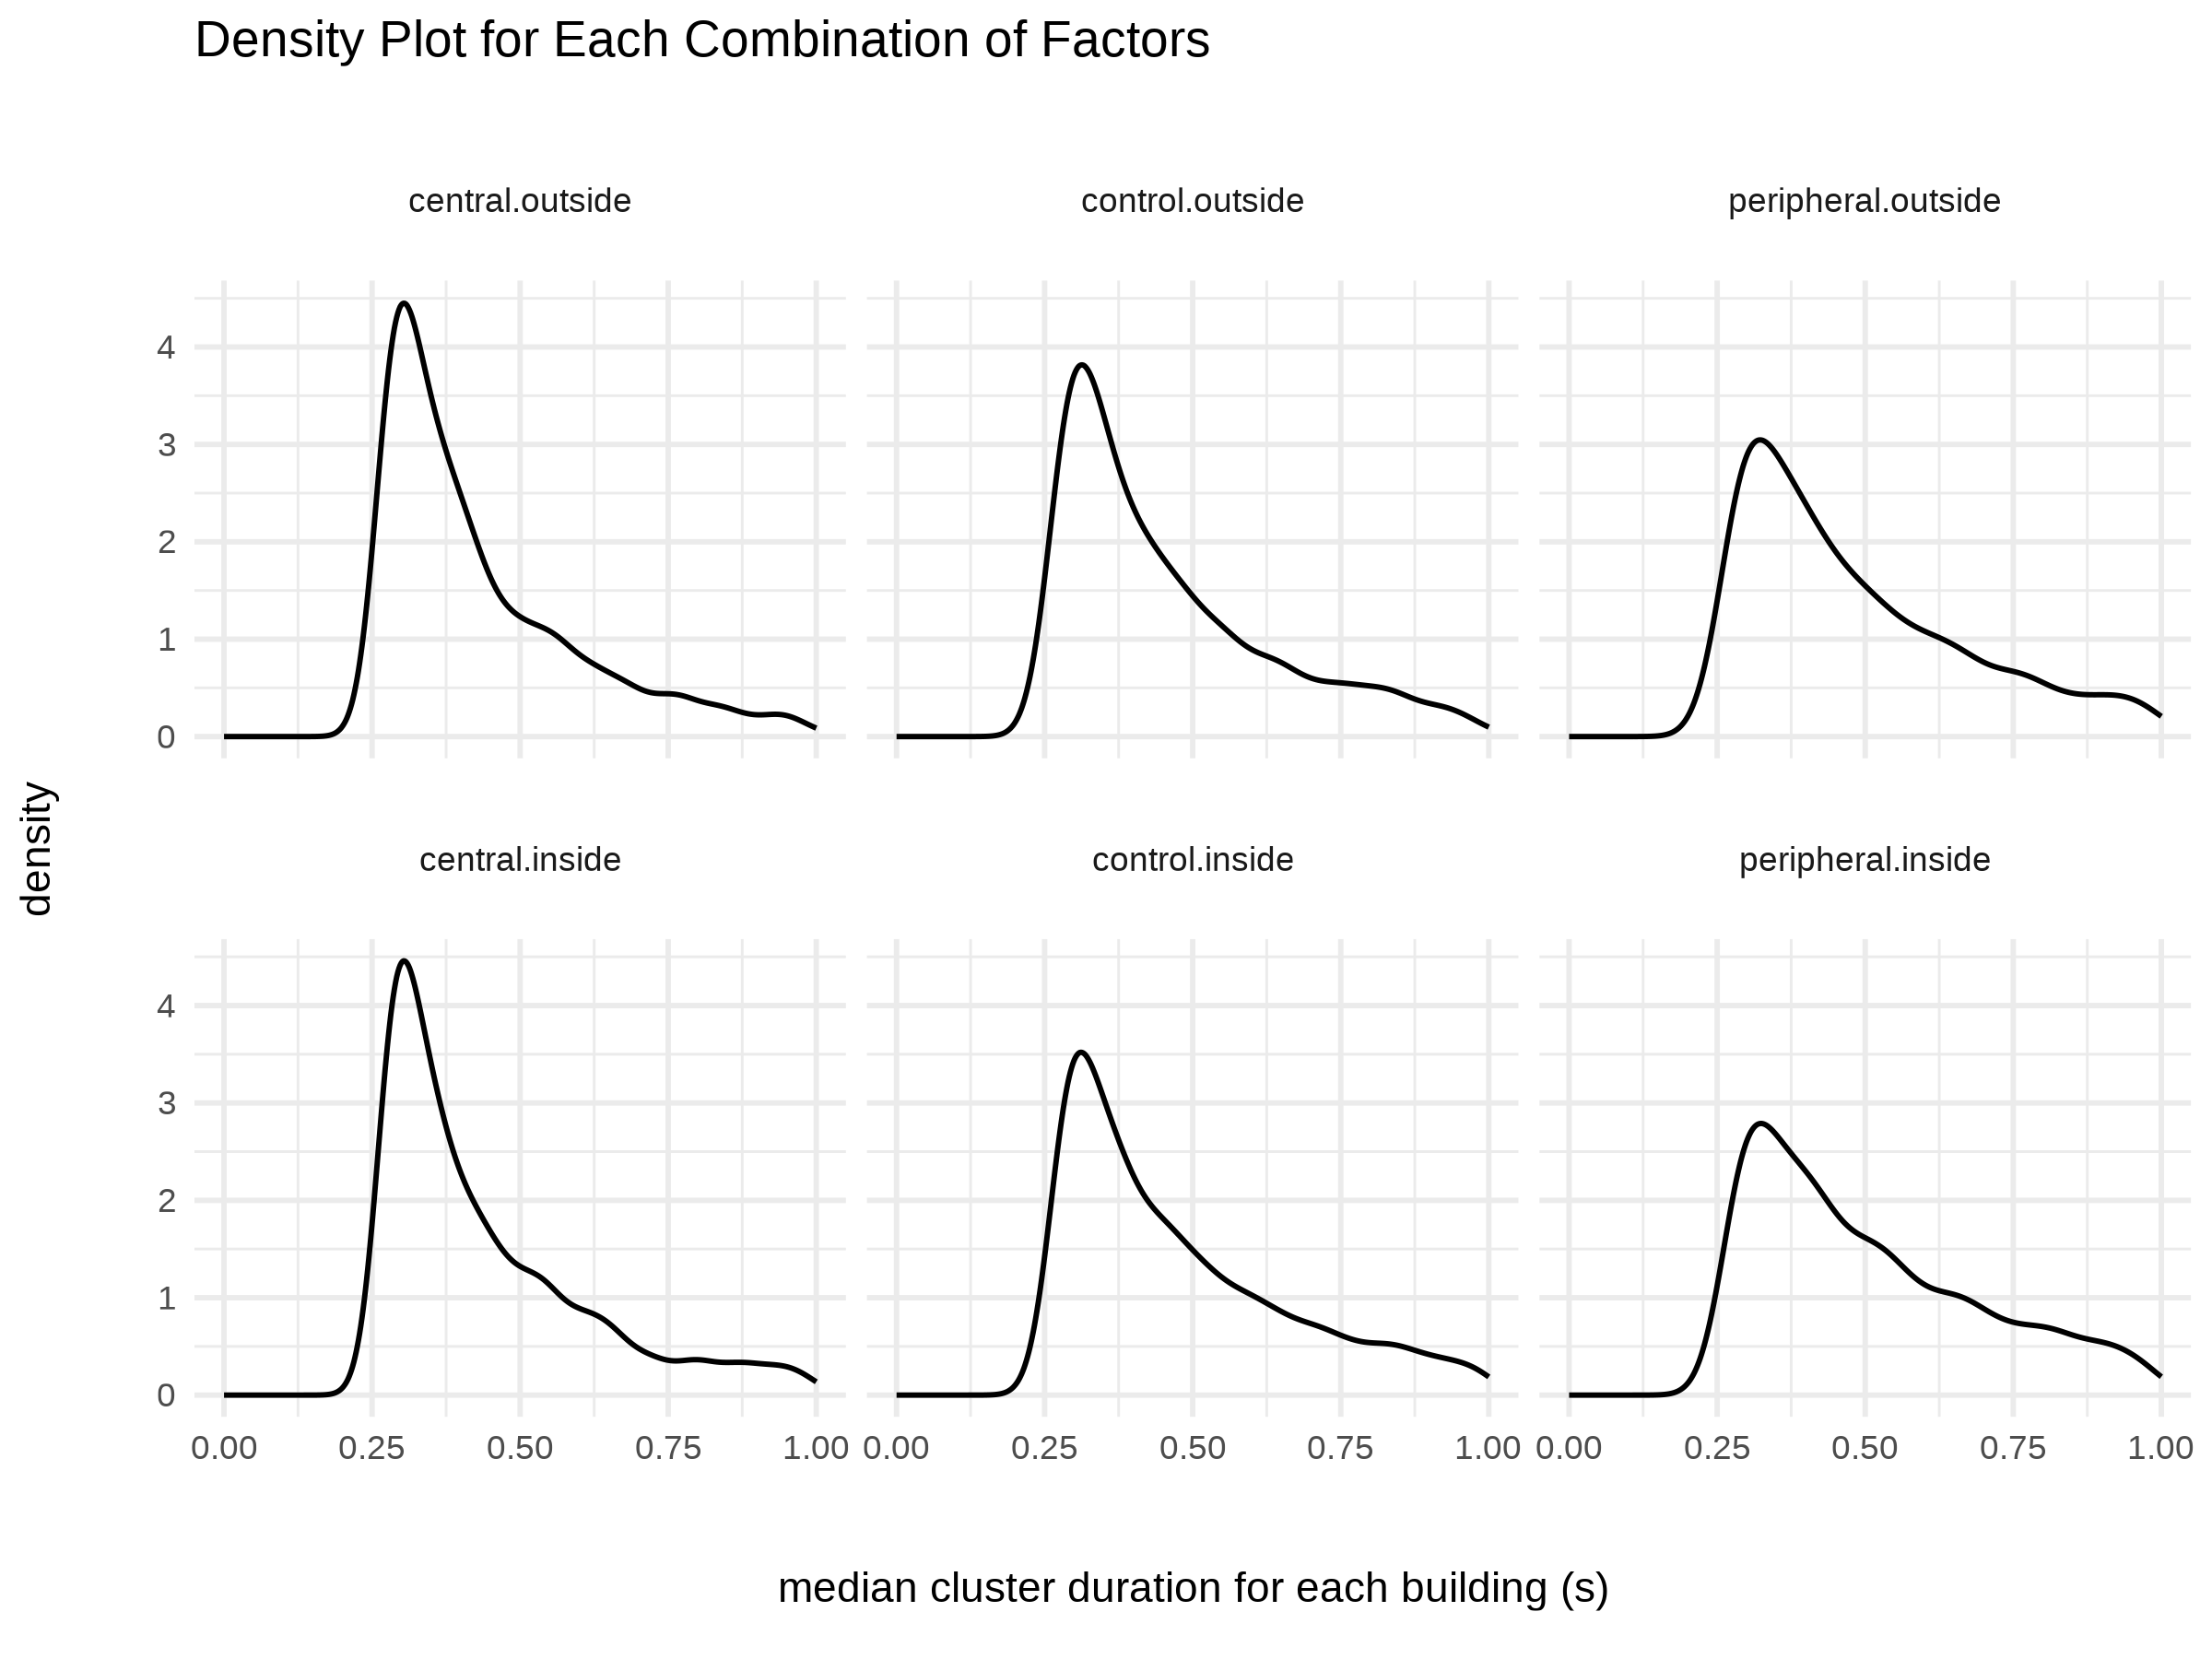

In [9]:
df_node |>
  ggplot(aes(x = clusterDuration)) +
  geom_density(alpha = 0.6) +  # Adjust alpha for transparency
  xlim(0,1)+
  facet_wrap(~ interaction(group, building_location)) +  # Facet by the interaction of the two factors
  theme_minimal() +
  labs(title = "Density Plot for Each Combination of Factors",
       x = "median cluster duration for each building (s)",
       y = "density")